# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Generate Pseudo-Absence Data
Absence data must be generated for these classifiers, and different quantities must be generated for types of classifiers, based on Barbet-Massin et al., 2012.

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [96]:
import os
# os.mkdir("inputs", ex)
# os.mkdir("outputs")
import subprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from pygam import LogisticGAM, s, f
from sklearn.tree import DecisionTreeClassifier
# out of all the glms, we choose the poisson - it does not have negative values, and varying variance???
# also we are looking for a scale of values up to 1000...
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pyimpute import impute
from sklearn import model_selection
from elapid import MaxentModel

Run the subprocess, R code to generate pseudo absences. Will be customized depending on the models

In [133]:
command = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', "2", "northerncorn"]
try:
    subprocess.run(command, capture_output=True, 
        text=True, check = True)
except subprocess.CalledProcessError as e:
    print(f"R Script failed with exit code {e.returncode}")
    print("Error Message:\n", e.stderr)

### Converting shapefiles (.shp) to geopandas dataframe

In [134]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf = gpd.GeoDataFrame.from_file('data/ncr.shp')
ncr_gdf.sample(5)

,CLASS,geometry
538,1.0,POINT (-80.73532 43.12289)
2321,1.0,POINT (-93.6171 42.03251)
1256,0.0,POINT (-121.78754 54.76114)
1771,0.0,POINT (-84.44415 53.81632)
2028,0.0,POINT (-140.96528 60.29624)


Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [135]:
print("Number of duplicates: ", ncr_gdf.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf.crs))
print("{} observations with {} columns".format(*ncr_gdf.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
2475 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

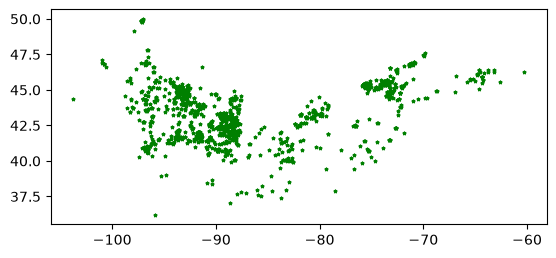

In [136]:
ncr_gdf[ncr_gdf.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

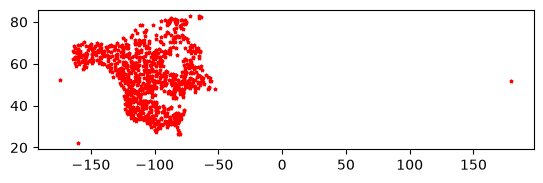

In [138]:
ncr_gdf[ncr_gdf.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [114]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = sorted(glob.glob(
    'worldclim/wc2.1_2.5m_bio_*.tif'))

# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(ras_feats), ' raster features.')
print(ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6


There are  7  raster features.
['worldclim\\wc2.1_2.5m_bio_13.tif', 'worldclim\\wc2.1_2.5m_bio_14.tif', 'worldclim\\wc2.1_2.5m_bio_15.tif', 'worldclim\\wc2.1_2.5m_bio_2.tif', 'worldclim\\wc2.1_2.5m_bio_4.tif', 'worldclim\\wc2.1_2.5m_bio_5.tif', 'worldclim\\wc2.1_2.5m_bio_6.tif']


In [115]:
import rasterio

with rasterio.open(ras_feats[0]) as src:
    raster_crs = src.crs

ncr_gdf = ncr_gdf.to_crs(raster_crs)
 
print(ncr_gdf.crs)


GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


Generate raster maps of suitability. Also separate test sets from the rest for cross validation

In [116]:
from pyimpute import load_training_vector
from pyimpute import load_targets
import numpy as np
import pandas as pd

train_xs, train_ys = load_training_vector(ncr_gdf, ras_feats, response_field='CLASS')

x_df = pd.DataFrame(train_xs)
x_df = x_df.apply(pd.to_numeric, errors="coerce")
x_df = x_df.replace([np.inf, -np.inf], np.nan)

y_ser = pd.Series(train_ys)

mask = x_df.notna().all(axis=1) & y_ser.notna()

# Apply mask to both X and y
train_xs_clean = x_df.loc[mask].to_numpy(dtype=float)
train_ys_clean = y_ser.loc[mask].to_numpy()

print("Original samples:", len(train_xs))
print("Clean samples:", len(train_xs_clean))
print("Dropped samples:", len(train_xs) - len(train_xs_clean))


train_x, test_x, train_y, test_y = model_selection.train_test_split(train_xs_clean, train_ys_clean, test_size=0.25, random_state=42, stratify=train_ys_clean)
# train_xs.shape, train_ys.shape
train_x.shape, test_x.shape, train_y.shape, test_y.shape

Original samples: 2475
Clean samples: 2469
Dropped samples: 6


((1851, 7), (618, 7), (1851,), (618,))

In [117]:
print(train_x)

[[ 120.           19.           52.09820938 ... 1171.1328125
    28.72800064  -14.72399998]
 [ 116.           24.           47.18858719 ... 1158.42163086
    28.02799988  -15.18400002]
 [  45.            9.           53.91744614 ... 1547.34106445
    17.73999977  -32.44799805]
 ...
 [ 127.           38.           36.90265274 ...  769.12902832
    17.9640007   -11.69200039]
 [  93.           56.           15.69612122 ... 1159.69689941
    26.71199989  -16.25600052]
 [ 102.           26.           39.3888855  ... 1078.18530273
    27.70000076  -13.49600029]]


Classifier implementation

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score

sample_weights = compute_sample_weight(class_weight='balanced', y=train_y)
k = 4
kf = model_selection.KFold(n_splits=k, shuffle=True, random_state=42)

### random forest ###

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1)
rf_accuracy_scores = model_selection.cross_val_score(rf, train_x, train_y, cv=kf, scoring='accuracy')
print("rf %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, rf_accuracy_scores.mean() * 100, rf_accuracy_scores.std() * 200))
rf.fit(train_x, train_y)
rf_train_pred = rf.predict(train_x)
rf_test_pred = rf.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, rf_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, rf_test_pred))

### LDA ###

lda = LinearDiscriminantAnalysis()
lda_accuracy_scores = model_selection.cross_val_score(lda, train_x, train_y, cv = kf, scoring='accuracy')
print("lda %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, lda_accuracy_scores.mean() * 100, lda_accuracy_scores.std() * 200))
lda.fit(train_x, train_y)
lda_train_pred = lda.predict(train_x)
lda_test_pred = lda.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, lda_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, lda_test_pred))

### decision tree classifier ###

dtc = DecisionTreeClassifier()
dtc_accuracy_scores = model_selection.cross_val_score(dtc, train_x, train_y, cv = kf, scoring='accuracy')
print("dtc %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, dtc_accuracy_scores.mean() * 100, dtc_accuracy_scores.std() * 200))
dtc.fit(train_x, train_y)
dtc_train_pred = dtc.predict(train_x)
dtc_test_pred = dtc.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, dtc_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, dtc_test_pred))

### logistic regression ###
lr = LogisticRegression(max_iter=5000)
lr_accuracy_scores = model_selection.cross_val_score(lr, train_x, train_y, cv = kf, scoring='accuracy')
print("lr %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, lr_accuracy_scores.mean() * 100, lr_accuracy_scores.std() * 200))
lr.fit(train_x, train_y)
lr_train_pred = lr.predict(train_x)
lr_test_pred = lr.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, lr_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, lr_test_pred))

### xgb classifier ###
xgb = XGBClassifier()
xgb_accuracy_scores = model_selection.cross_val_score(xgb, train_x, train_y, cv = kf, scoring='accuracy')
print("xgb %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, xgb_accuracy_scores.mean() * 100, xgb_accuracy_scores.std() * 200))
xgb.fit(train_x, train_y)
xgb_train_pred = xgb.predict(train_x)
xgb_test_pred = xgb.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, xgb_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, xgb_test_pred))

### light gbm ###
lgbm = LGBMClassifier()
lgbm_accuracy_scores = model_selection.cross_val_score(lgbm, train_x, train_y, cv = kf, scoring='accuracy')
print("lgbm %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, lgbm_accuracy_scores.mean() * 100, lgbm_accuracy_scores.std() * 200))
lgbm.fit(train_x, train_y)
lgbm_train_pred = lgbm.predict(train_x)
lgbm_test_pred = lgbm.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, lgbm_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, lgbm_test_pred))

### MARS ###
# mars = make_pipeline(SplineTransformer(degree=1, n_knots=10, include_bias=False), LinearRegression())
# mars_accuracy_scores = model_selection.cross_val_score(mars, train_x, train_y, cv = kf, scoring='accuracy')
# print("mars %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
#           % (k, mars_accuracy_scores.mean() * 100, mars_accuracy_scores.std() * 200))
# mars.fit(train_x, train_y)
# mars_train_pred = mars.predict(train_x)
# mars_test_pred = mars.predict(test_x)
# print("Train balanced accuracy:", balanced_accuracy_score(train_y, mars_train_pred))
# print("Test balanced accuracy:", balanced_accuracy_score(test_y, mars_test_pred))




    # # 'et': (ExtraTreesClassifier()),
    # 'lda': (LinearDiscriminantAnalysis()),
    # 'dtc': (DecisionTreeClassifier()),
    # 'glm': (LogisticRegression()),
    # 'xgb': (XGBClassifier()),
    # 'lgbm': (LGBMClassifier()),
    # # 'maxent': (MaxentModel())

ALT_MAP = {
    'gam': (GAM()),
    'mars': (make_pipeline(SplineTransformer(degree=1, n_knots=10, include_bias=False), LinearRegression()))
}



# for name, (model) in CLASS_MAP.items():
#      # k-fold
#     # spatial prediction
#     score = model.score(test_x, test_y)
#     print(name + " score: %f" % (score))
    # impute(target_xs, model, raster_info, outdir='outputs/' + name + '-images',
    #        class_prob=True, certainty=True)

rf 4-fold Cross Validation Accuracy: 97.73 (+/- 0.78)
Train balanced accuracy: 0.9865967690738286
Test balanced accuracy: 0.9799239130434783
lda 4-fold Cross Validation Accuracy: 89.46 (+/- 2.18)
Train balanced accuracy: 0.8766637428246737
Test balanced accuracy: 0.8766413043478261
dtc 4-fold Cross Validation Accuracy: 96.16 (+/- 1.03)
Train balanced accuracy: 1.0
Test balanced accuracy: 0.9684891304347826
lr 4-fold Cross Validation Accuracy: 92.71 (+/- 1.25)
Train balanced accuracy: 0.9197684026372732
Test balanced accuracy: 0.905695652173913
xgb 4-fold Cross Validation Accuracy: 98.22 (+/- 1.31)
Train balanced accuracy: 1.0
Test balanced accuracy: 0.9872826086956521
[LightGBM] [Info] Number of positive: 814, number of negative: 574
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1488
[LightGBM] [Info] Number of data points in the train set: 13

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.conda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.conda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 829, number of negative: 559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1486
[LightGBM] [Info] Number of data points in the train set: 1388, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.597262 -> initscore=0.394071
[LightGBM] [Info] Start training from score 0.394071
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 830, number of negative: 558
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1487
[LightGBM] [Info] Number o

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.conda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.conda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 833, number of negative: 556
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1486
[LightGBM] [Info] Number of data points in the train set: 1389, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.599712 -> initscore=0.404265
[LightGBM] [Info] Start training from score 0.404265
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
lgbm 4-fold Cross Validation Accuracy: 98.43 (+/- 0.56)
[LightGBM] [Info] Number of positive: 1102, number of negative: 749
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[Li

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.conda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.conda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [119]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []
acc_scores = []
logloss_scores = []

gam = LogisticGAM(s(0) + s(1) + s(2))

for train_idx, test_idx in cv.split(train_x, train_y):
    X_train, X_test = train_x[train_idx], train_x[test_idx]
    y_train, y_test = train_y[train_idx], train_y[test_idx]
    gam.fit(X_train, y_train)

    y_prob = gam.predict_proba(X_test)

    y_pred = gam.predict(X_test)

    auc_scores.append(roc_auc_score(y_test, y_prob))
    acc_scores.append(accuracy_score(y_test, y_pred))
    logloss_scores.append(log_loss(y_test, y_prob))

print("Mean AUC:", np.mean(auc_scores))
print("Mean accuracy:", np.mean(acc_scores))
print("Mean log loss:", np.mean(logloss_scores))


### gam ###
## pygam does not support cross val, find alternatives?


# gam_accuracy_scores = gam.gridsearch()
# model_selection.cross_val_score(gam, train_x, train_y, cv = kf, scoring='accuracy')
# print("gam %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
#           % (k, gam_accuracy_scores.mean() * 100, gam_accuracy_scores.std() * 200))

gam_train_pred = gam.predict(train_x)
gam_test_pred = gam.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, gam_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, gam_test_pred))

Mean AUC: 0.9374656109517538
Mean accuracy: 0.9173482916879145
Mean log loss: 0.26502467342369307
Train balanced accuracy: 0.9114342414205026
Test balanced accuracy: 0.8838478260869566


Averaging the outputs of the models, and plotting it onto a map

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\4195826174.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\4195826174.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\4195826174.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
C:\Us

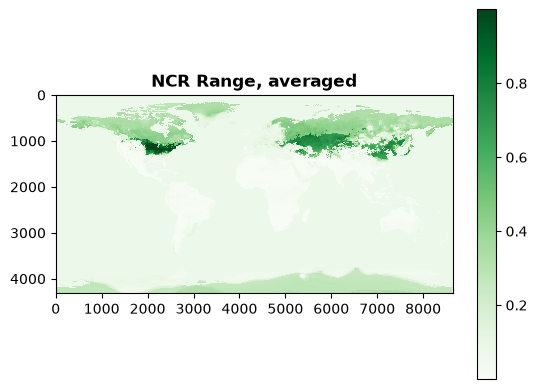

In [ ]:
# NOT LORE ACCURATE ANYMORE
# from pylab import plt
# # define spatial plotter
# def plotit(x, title, cmap="Blues"):
#     plt.imshow(x, cmap=cmap, interpolation='nearest')
#     plt.colorbar()
#     plt.title(title, fontweight = 'bold')

# distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
# distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
# distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
# distr_lgbm =  rasterio.open("outputs/lgbm-images/probability_1.0.tif").read(1)
# distr_averaged = (distr_rf + distr_et + distr_xgb + distr_lgbm)/4  

# plotit(distr_averaged, "NCR Range, averaged", cmap="Greens")

In [139]:
future_stacks = ["worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040.tif", "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp245_2021-2040.tif",
                "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp370_2021-2040.tif", "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp585_2021-2040.tif"]
out_dir = "future_split_bands"

from rasterio.windows import from_bounds

training_feature_names = [
    "bio13",
    "bio14",
    "bio15",
    "bio2",
    "bio4",
    "bio5",
    "bio6"
]

future_band_map = {
    "bio13": 13,
    "bio14": 14,
    "bio15": 15,
    "bio2": 2,
    "bio4": 4,
    "bio5": 5,
    "bio6": 6
}
min_lon = -170
max_lon = -52
min_lat = 24
max_lat = 83.5

future_ras_feats = []

for index, stack in enumerate(future_stacks):
    with rasterio.open(stack) as src:
        print("Band count:", src.count)
        print("CRS:", src.crs)
        print("Shape:", src.shape)
        print("Bounds:", src.bounds)
        print("Descriptions:", src.descriptions)
        print("Indexes:", src.indexes)
# with rasterio.open(future_stack) as src:
        window = from_bounds(
                min_lon,
                min_lat,
                max_lon,
                max_lat,
                transform=src.transform
        )
        data = src.read(window=window)

        transform = src.window_transform(window)

        profile = src.profile.copy()
        profile.update(height=data.shape[1],
                width=data.shape[2],
                transform=transform)

        for feature_name in training_feature_names:
            band_index = future_band_map[feature_name]

            band = src.read(band_index)

            out_path = os.path.join(f"{out_dir}_{index}", f"future_{feature_name}.tif")

            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(band, 1)
                dst.set_band_description(1, feature_name)

        # future_ras_feats.append(out_path)
    future_ras_feats = sorted(glob.glob(
        'future_split_bands_1/future_bio*.tif')) 
    future_target_xs, future_raster_info = load_targets(future_ras_feats)

Band count: 19
CRS: EPSG:4326
Shape: (4320, 8640)
Bounds: BoundingBox(left=-180.0, bottom=-89.99999999999997, right=179.99999999999994, top=90.0)
Descriptions: ('wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_1', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_2', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_3', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_4', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_5', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_6', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_7', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_8', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_9', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_10', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_11', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_12', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_13', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_14', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_15', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_16', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\1014301595.py:61: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = src.read(band_index)


RasterioIOError: Attempt to create new tiff file 'future_split_bands_0\future_bio13.tif' failed: future_split_bands_0\future_bio13.tif: No such file or directory

In [123]:
# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(future_ras_feats), ' raster features.')
print(future_ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6

There are  7  raster features.
['future_split_bands\\future_bio13.tif', 'future_split_bands\\future_bio14.tif', 'future_split_bands\\future_bio15.tif', 'future_split_bands\\future_bio2.tif', 'future_split_bands\\future_bio4.tif', 'future_split_bands\\future_bio5.tif', 'future_split_bands\\future_bio6.tif']


In [124]:
impute(future_target_xs, rf, future_raster_info, outdir='outputs/' + 'rf1' + '-images',
           class_prob=True, certainty=True)

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\2503031681.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf = rasterio.open("outputs/rf1-images/probability_1.0.tif").read(1)


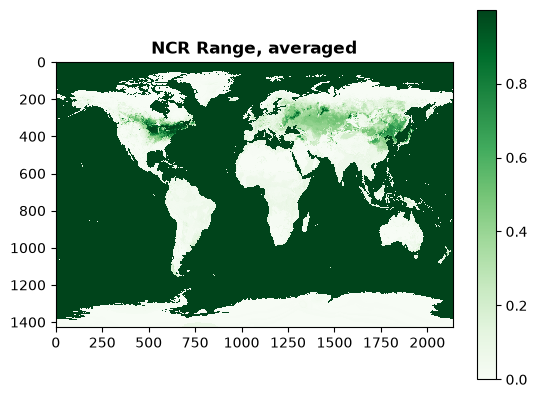

In [132]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

distr_rf = rasterio.open("outputs/rf1-images/probability_1.0.tif").read(1)
plotit(distr_rf, "NCR Range, averaged", cmap="Greens")